# Exploración y Limpieza de Datos - Wine Quality Dataset

Este notebook contiene el proceso de **Data Wrangling** y **Exploratory Data Analysis (EDA)** del dataset de calidad de vinos, que incluye muestras de vino tinto y blanco portugués "Vinho Verde".

## 1. Importación de Librerías y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos para las visualizaciones
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Carga de Datos

Cargamos los dos archivos CSV (vino tinto y vino blanco) y los combinamos en un único DataFrame agregando una columna para identificar el tipo de vino.

In [2]:
# Carga de los datasets
df_red = pd.read_csv('Wine/winequality-red.csv', sep=';')
df_white = pd.read_csv('Wine/winequality-white.csv', sep=';')

# Agregamos columna para identificar el tipo de vino
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

# Combinamos ambos datasets
df = pd.concat([df_red, df_white], ignore_index=True)

print(f"Dataset combinado creado exitosamente")
print(f"Vinos tintos: {len(df_red)} muestras")
print(f"Vinos blancos: {len(df_white)} muestras")
print(f"Total: {len(df)} muestras")

Dataset combinado creado exitosamente
Vinos tintos: 1599 muestras
Vinos blancos: 4898 muestras
Total: 6497 muestras


## 3. Exploración Inicial

Realizamos una primera inspección del dataset para entender su estructura, dimensiones y contenido.

In [3]:
# Dimensiones del dataset
print("=== Dimensiones del Dataset ===")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print()

# Nombres de las columnas
print("=== Columnas ===")
for col in df.columns:
    print(f"  - {col}")
print()

# Información general
print("=== Información del Dataset ===")
df.info()

=== Dimensiones del Dataset ===
Filas: 6497
Columnas: 13

=== Columnas ===
  - fixed acidity
  - volatile acidity
  - citric acid
  - residual sugar
  - chlorides
  - free sulfur dioxide
  - total sulfur dioxide
  - density
  - pH
  - sulphates
  - alcohol
  - quality
  - wine_type

=== Información del Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             

In [4]:
# Primeras filas del dataset
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,red
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,red
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,red
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,red


In [5]:
# Últimas filas del dataset
df.tail(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
6487,6.8,0.220,0.36,1.20,0.052,38.0,127.0,0.99330,3.04,0.54,9.2,5,white
6488,4.9,0.235,0.27,11.75,0.030,34.0,118.0,0.99540,3.07,0.50,9.4,6,white
6489,6.1,0.340,0.29,2.20,0.036,25.0,100.0,0.98938,3.06,0.44,11.8,6,white
6490,5.7,0.210,0.32,0.90,0.038,38.0,121.0,0.99074,3.24,0.46,10.6,6,white
6491,6.5,0.230,0.38,1.30,0.032,29.0,112.0,0.99298,3.29,0.54,9.7,5,white
6492,6.2,0.210,0.29,1.60,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.320,0.36,8.00,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.240,0.19,1.20,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.290,0.30,1.10,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white
6496,6.0,0.210,0.38,0.80,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,white


## 4. Limpieza de Datos

Verificamos la presencia de duplicados, valores nulos y validamos los tipos de datos.

In [6]:
# Verificación de valores nulos
print("=== Valores Nulos por Columna ===")
null_counts = df.isnull().sum()
print(null_counts)
print(f"\nTotal de valores nulos: {null_counts.sum()}")

=== Valores Nulos por Columna ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

Total de valores nulos: 0


In [7]:
# Verificación de duplicados
duplicates = df.duplicated().sum()
print(f"=== Filas Duplicadas ===")
print(f"Total de filas duplicadas: {duplicates}")
print(f"Porcentaje del dataset: {(duplicates/len(df)*100):.2f}%")

=== Filas Duplicadas ===
Total de filas duplicadas: 1177
Porcentaje del dataset: 18.12%


In [8]:
# Eliminación de duplicados
print(f"Shape antes de eliminar duplicados: {df.shape}")
df = df.drop_duplicates()
print(f"Shape después de eliminar duplicados: {df.shape}")
print(f"Filas eliminadas: {df_red.shape[0] + df_white.shape[0] - df.shape[0]}")

Shape antes de eliminar duplicados: (6497, 13)
Shape después de eliminar duplicados: (5320, 13)
Filas eliminadas: 1177


In [9]:
# Validación de tipos de datos
print("=== Tipos de Datos ===")
df.dtypes

=== Tipos de Datos ===


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
wine_type                   str
dtype: object

In [10]:
# Convertir wine_type a tipo categórico para optimizar memoria
df['wine_type'] = df['wine_type'].astype('category')
df['quality'] = df['quality'].astype('int64')

print("=== Tipos de Datos después de la conversión ===")
df.dtypes

=== Tipos de Datos después de la conversión ===


fixed acidity            float64
volatile acidity         float64
citric acid              float64
residual sugar           float64
chlorides                float64
free sulfur dioxide      float64
total sulfur dioxide     float64
density                  float64
pH                       float64
sulphates                float64
alcohol                  float64
quality                    int64
wine_type               category
dtype: object

## 5. Detección de Outliers

Utilizamos el método del Rango Intercuartílico (IQR) para identificar valores atípicos en las variables numéricas.

In [11]:
# Función para detectar outliers usando el método IQR
def detect_outliers_iqr(df, columns):
    """
    Detecta outliers usando el método IQR (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    Retorna un DataFrame con el resumen de outliers por columna.
    """
    outlier_summary = []
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        outlier_summary.append({
            'column': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outliers_count': len(outliers),
            'outliers_percentage': len(outliers) / len(df) * 100
        })
    
    return pd.DataFrame(outlier_summary)

# Detectar outliers en las columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = detect_outliers_iqr(df, numeric_cols)
outlier_summary

,column,Q1,Q3,IQR,lower_bound,upper_bound,outliers_count,outliers_percentage
0,fixed acidity,6.4000,7.70000,1.30000,4.450000e+00,9.650000,304,5.714286
1,volatile acidity,0.2300,0.41000,0.18000,-4.000000e-02,0.680000,279,5.244361
2,citric acid,0.2400,0.40000,0.16000,-5.551115e-17,0.640000,143,2.687970
3,residual sugar,1.8000,7.50000,5.70000,-6.750000e+00,16.050000,141,2.650376
4,chlorides,0.0380,0.06600,0.02800,-4.000000e-03,0.108000,237,4.454887
5,free sulfur dioxide,16.0000,41.00000,25.00000,-2.150000e+01,78.500000,44,0.827068
6,total sulfur dioxide,74.0000,153.25000,79.25000,-4.487500e+01,272.125000,10,0.187970
7,density,0.9922,0.99677,0.00457,9.853450e-01,1.003625,3,0.056391
8,pH,3.1100,3.33000,0.22000,2.780000e+00,3.660000,49,0.921053
9,sulphates,0.4300,0.60000,0.17000,1.750000e-01,0.855000,163,3.063910


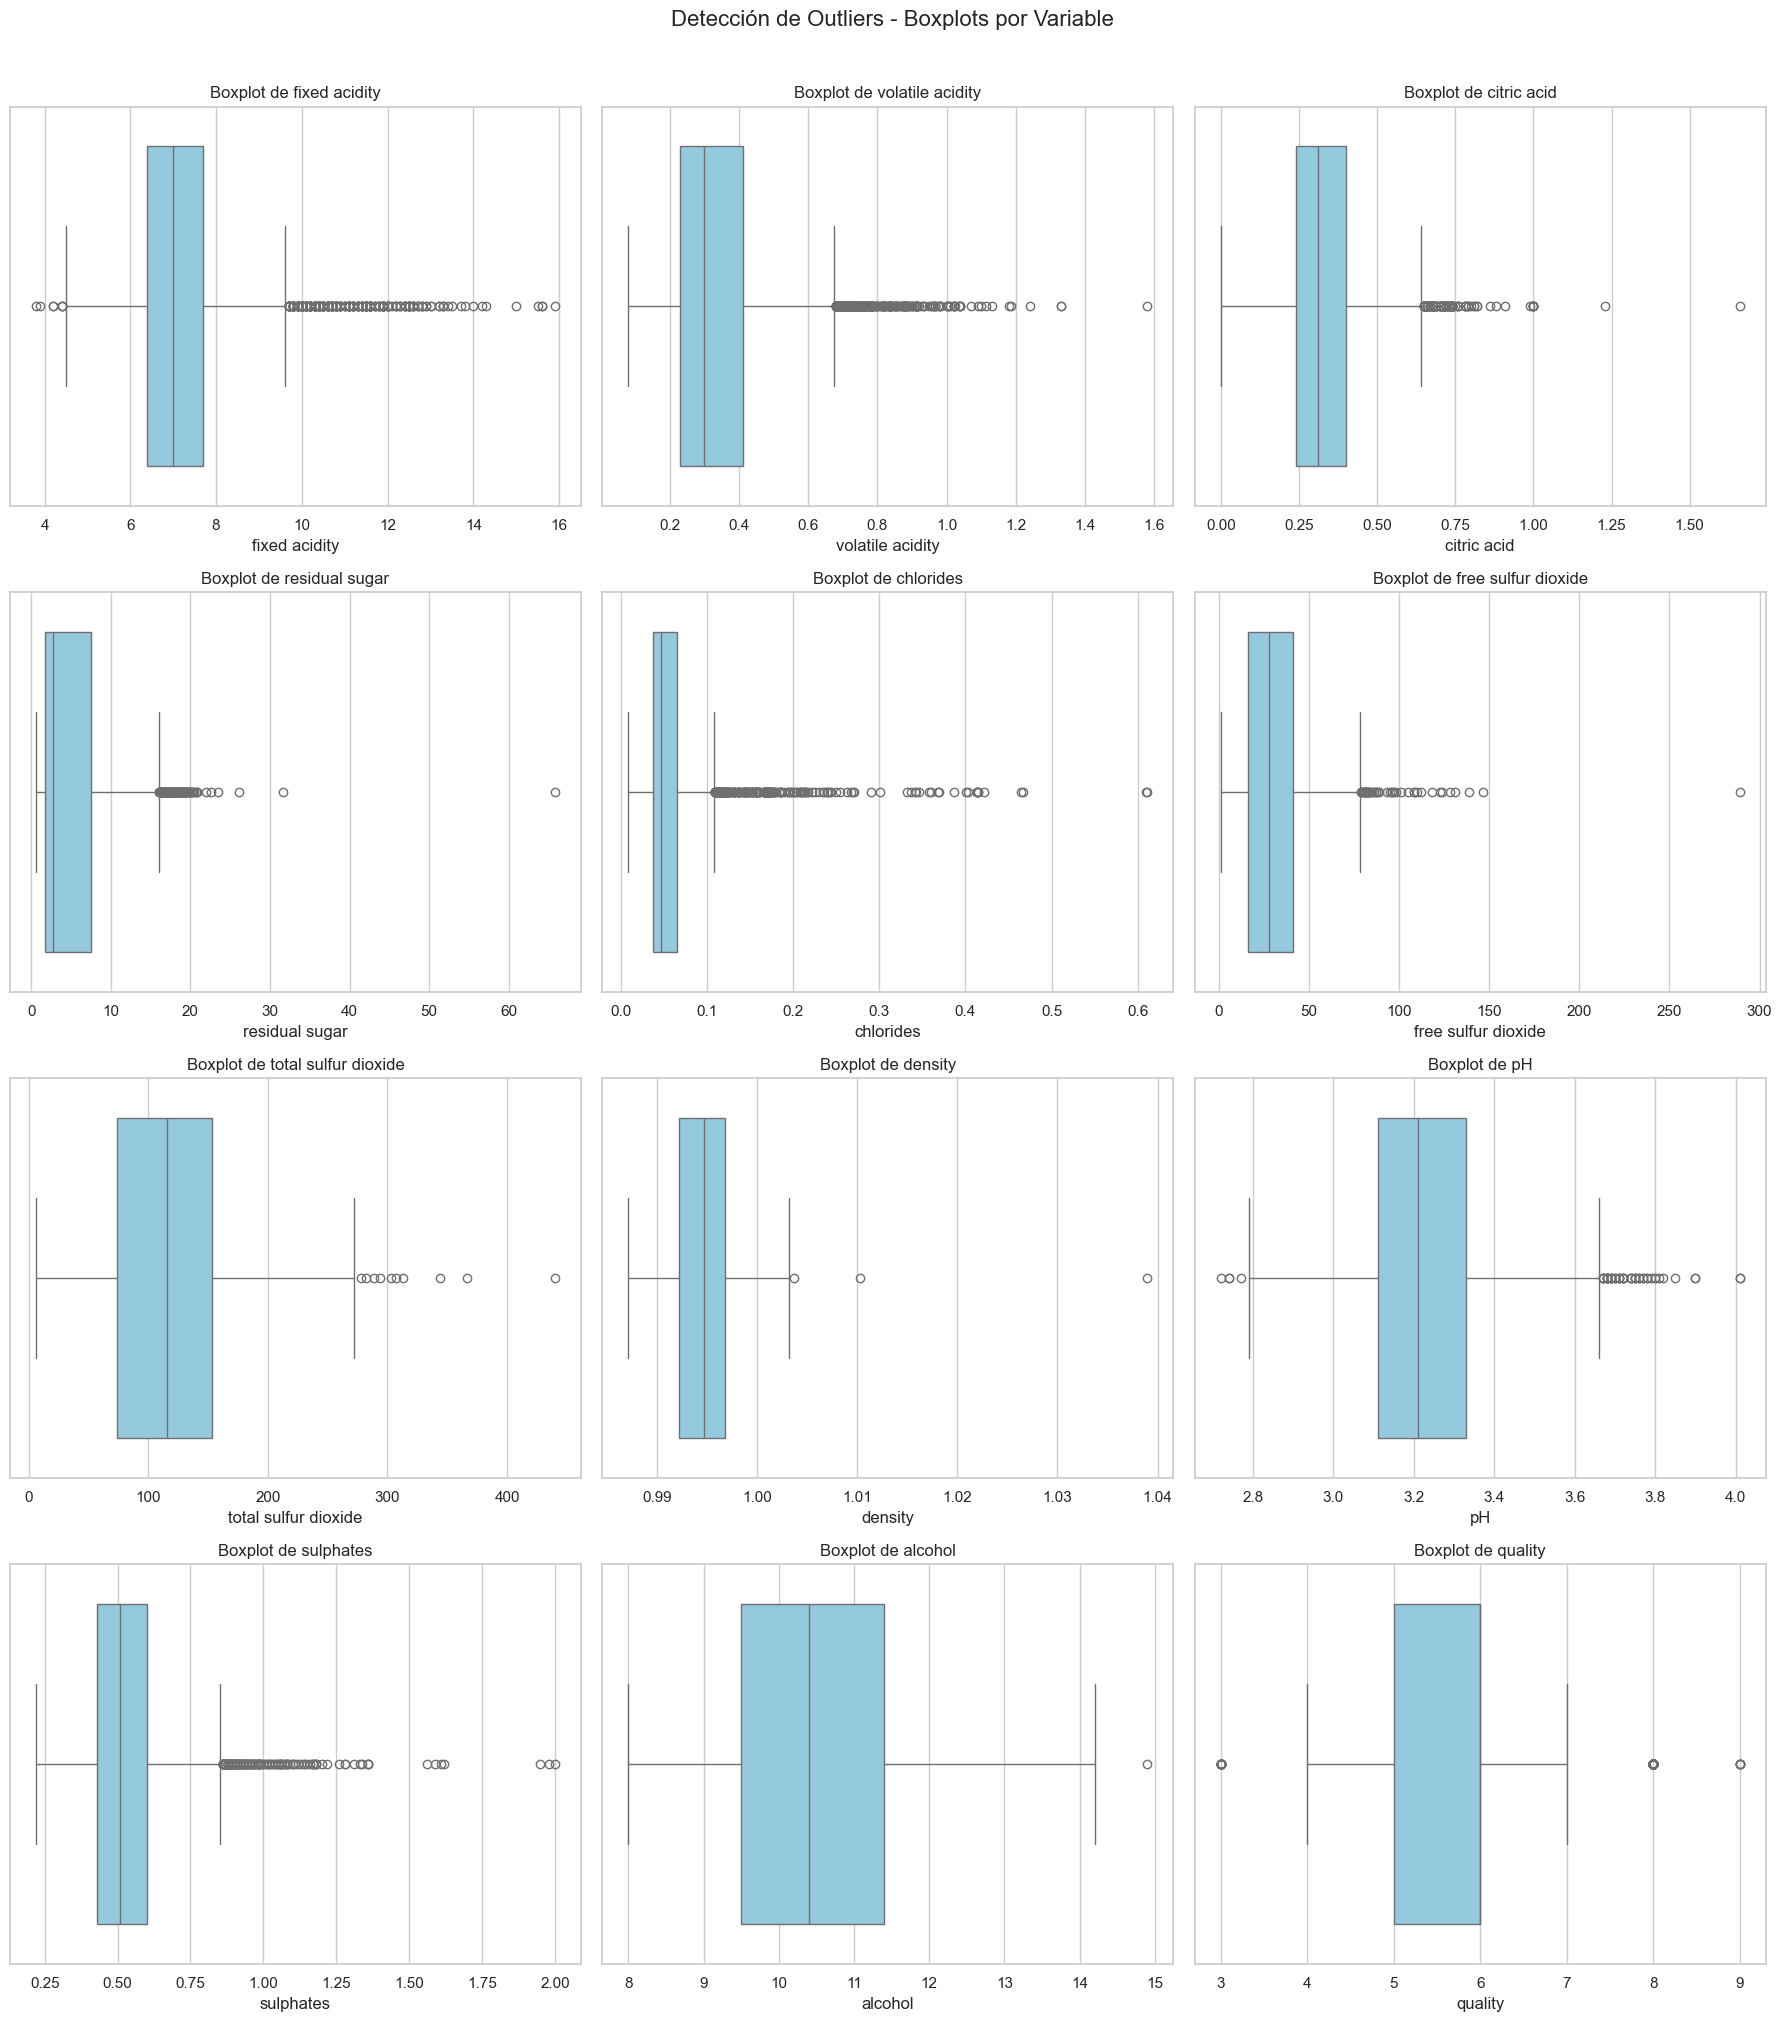


=== Análisis de Outliers ===
Variables con más outliers:
  - fixed acidity: 304 outliers (5.7%)
  - volatile acidity: 279 outliers (5.2%)
  - chlorides: 237 outliers (4.5%)
  - quality: 183 outliers (3.4%)
  - sulphates: 163 outliers (3.1%)


In [12]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot de {col}', fontsize=12)
    axes[i].set_xlabel(col)

# Eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Detección de Outliers - Boxplots por Variable', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print("\n=== Análisis de Outliers ===")
print(f"Variables con más outliers:")
top_outliers = outlier_summary.nlargest(5, 'outliers_count')
for _, row in top_outliers.iterrows():
    print(f"  - {row['column']}: {row['outliers_count']} outliers ({row['outliers_percentage']:.1f}%)")

## 6. Estadísticas Descriptivas

Analizamos las estadísticas generales del dataset y comparamos las características entre vinos tintos y blancos.

In [13]:
# Estadísticas descriptivas generales
print("=== Estadísticas Descriptivas Generales ===")
df.describe()

=== Estadísticas Descriptivas Generales ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [14]:
# Estadísticas agrupadas por tipo de vino
print("=== Estadísticas por Tipo de Vino ===")
df.groupby('wine_type').describe()

=== Estadísticas por Tipo de Vino ===


fixed acidity                                               \
                  count      mean      std  min  25%  50%  75%   max   
wine_type                                                              
red              1359.0  8.310596  1.73699  4.6  7.1  7.9  9.2  15.9   
white            3961.0  6.839346  0.86686  3.8  6.3  6.8  7.3  14.2   

          volatile acidity            ... alcohol       quality            \
                     count      mean  ...     75%   max   count      mean   
wine_type                             ...                                   
red                 1359.0  0.529478  ...    11.1  14.9  1359.0  5.623252   
white               3961.0  0.280538  ...    11.4  14.2  3961.0  5.854835   

                                              
                std  min  25%  50%  75%  max  
wine_type                                     
red        0.823578  3.0  5.0  6.0  6.0  8.0  
white      0.890683  3.0  5.0  6.0  6.0  9.0  

[2 rows x 96 columns]

In [15]:
# Estadísticas agrupadas por calidad
print("=== Estadísticas por Calidad ===")
df.groupby('quality').agg({
    'fixed acidity': 'mean',
    'volatile acidity': 'mean',
    'citric acid': 'mean',
    'alcohol': 'mean',
    'pH': 'mean',
    'sulphates': 'mean',
    'wine_type': 'count'
}).rename(columns={'wine_type': 'count'}).round(2)

=== Estadísticas por Calidad ===


,fixed acidity,volatile acidity,citric acid,alcohol,pH,sulphates,count
quality,,,,,,,
3,7.85,0.52,0.28,10.22,3.26,0.51,30
4,7.30,0.46,0.27,10.22,3.24,0.51,206
5,7.33,0.39,0.31,9.87,3.21,0.53,1752
6,7.17,0.32,0.32,10.65,3.22,0.53,2323
7,7.12,0.29,0.34,11.51,3.24,0.55,856
8,6.82,0.30,0.34,11.91,3.24,0.52,148
9,7.42,0.30,0.39,12.18,3.31,0.47,5


## 7. Distribución de la Variable Objetivo (Quality)

Analizamos la distribución de las puntuaciones de calidad y comparamos entre vinos tintos y blancos.

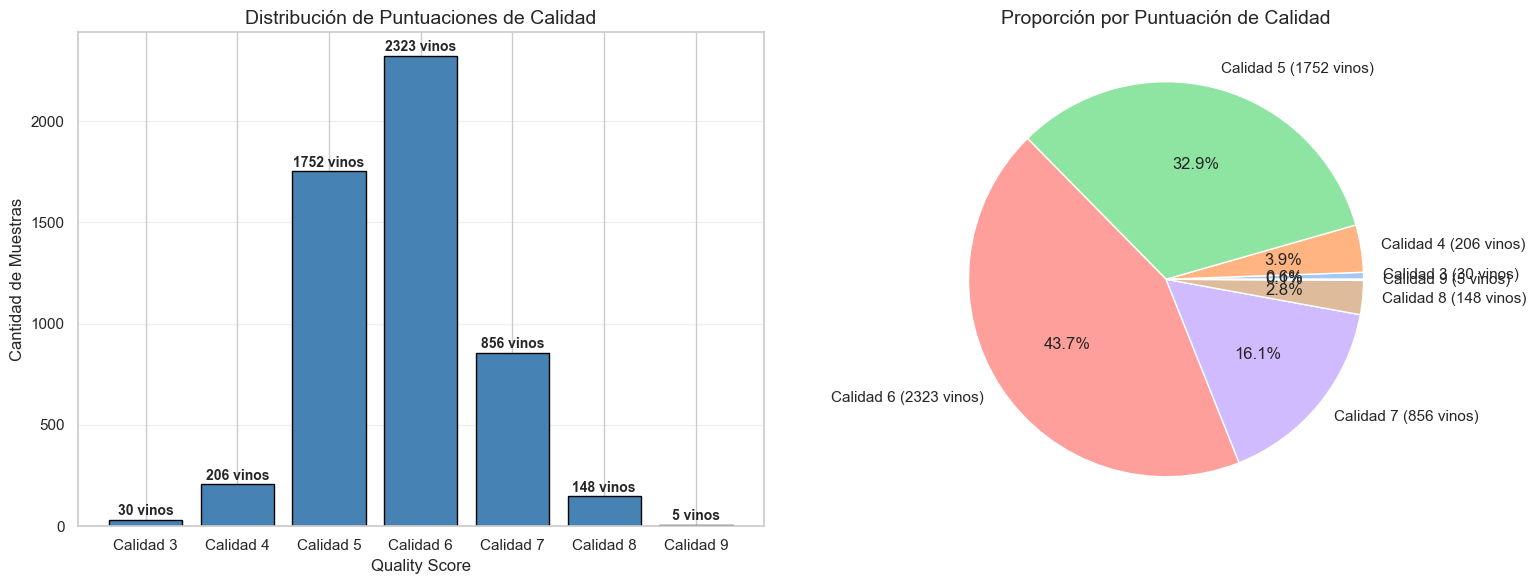


=== Observaciones ===
Rango de calidad: 3 - 9
Calidad promedio: 5.80
Calidad más frecuente: 6 (quality score)

El dataset está desbalanceado: la mayoría de los vinos tienen calidad entre 5 y 7.


In [17]:
# Distribución general de la calidad
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Puntuaciones de Calidad', fontsize=14)
axes[0].set_xlabel('Quality Score', fontsize=12)
axes[0].set_ylabel('Cantidad de Muestras', fontsize=12)
# Etiquetas más claras en el gráfico de barras
offset = quality_counts.max() * 0.01
for quality, count in zip(quality_counts.index, quality_counts.values):
    axes[0].text(quality, count + offset, f'{count} vinos', ha='center', fontweight='bold', fontsize=10)

axes[0].set_xticks(quality_counts.index)
axes[0].set_xticklabels([f'Calidad {int(q)}' for q in quality_counts.index])
axes[0].grid(axis='y', alpha=0.3)

# Hacer más explícitas las etiquetas del gráfico de torta
quality_counts.index = [f'Calidad {int(q)} ({c} vinos)' for q, c in zip(quality_counts.index, quality_counts.values)]

# Gráfico de pastel
axes[1].pie(quality_counts.values, labels=quality_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette('pastel', len(quality_counts)))
axes[1].set_title('Proporción por Puntuación de Calidad', fontsize=14)

plt.tight_layout()
plt.show()

print("\n=== Observaciones ===")
print(f"Rango de calidad: {df['quality'].min()} - {df['quality'].max()}")
print(f"Calidad promedio: {df['quality'].mean():.2f}")
print(f"Calidad más frecuente: {df['quality'].mode()[0]} (quality score)")
print(f"\nEl dataset está desbalanceado: la mayoría de los vinos tienen calidad entre 5 y 7.")

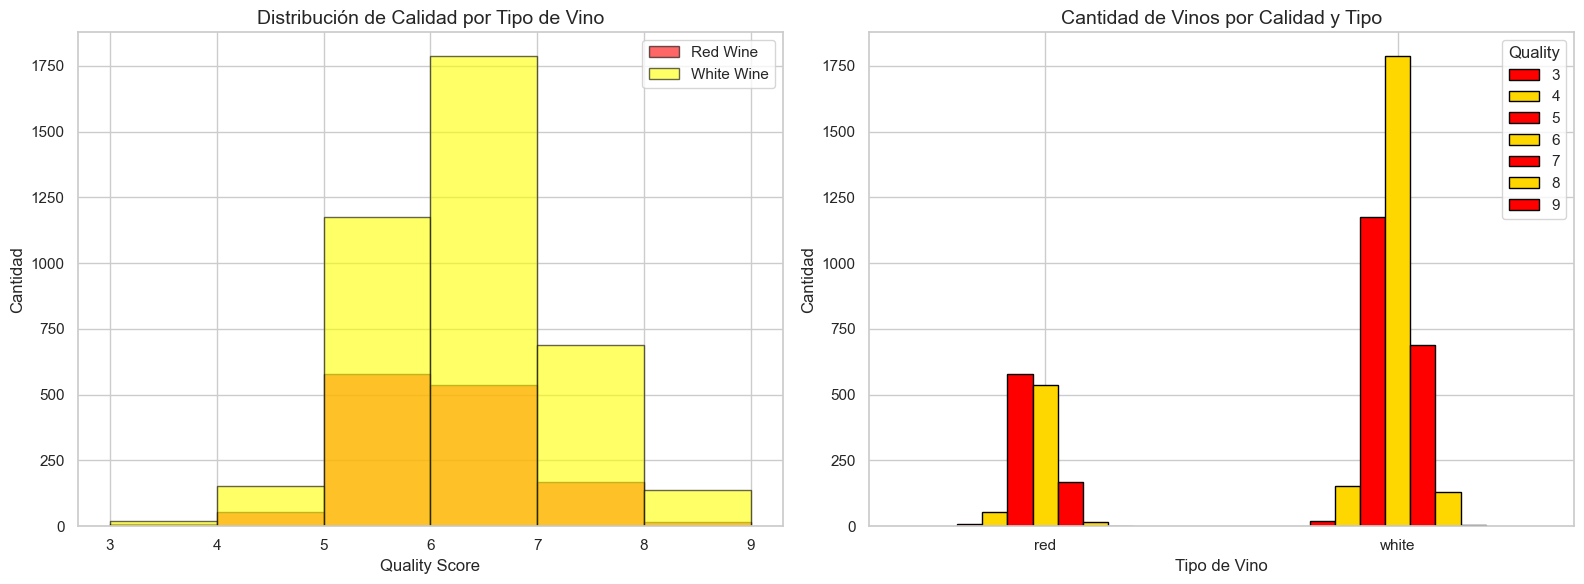


=== Comparación Red vs White ===
Calidad promedio (Red): 5.62
Calidad promedio (White): 5.85


In [18]:
# Comparación de calidad entre vinos tintos y blancos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma comparativo
df[df['wine_type'] == 'red']['quality'].hist(ax=axes[0], bins=range(3, 10), alpha=0.6, 
                                              label='Red Wine', color='red', edgecolor='black')
df[df['wine_type'] == 'white']['quality'].hist(ax=axes[0], bins=range(3, 10), alpha=0.6, 
                                                label='White Wine', color='yellow', edgecolor='black')
axes[0].set_title('Distribución de Calidad por Tipo de Vino', fontsize=14)
axes[0].set_xlabel('Quality Score', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)
axes[0].legend()

# Gráfico de barras apiladas
quality_by_type = pd.crosstab(df['wine_type'], df['quality'])
quality_by_type.plot(kind='bar', ax=axes[1], color=['red', 'gold'], edgecolor='black')
axes[1].set_title('Cantidad de Vinos por Calidad y Tipo', fontsize=14)
axes[1].set_xlabel('Tipo de Vino', fontsize=12)
axes[1].set_ylabel('Cantidad', fontsize=12)
axes[1].legend(title='Quality')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n=== Comparación Red vs White ===")
print(f"Calidad promedio (Red): {df[df['wine_type'] == 'red']['quality'].mean():.2f}")
print(f"Calidad promedio (White): {df[df['wine_type'] == 'white']['quality'].mean():.2f}")

## 8. Análisis de Correlación

Examinamos las correlaciones entre las variables para identificar relaciones importantes y las características más asociadas con la calidad del vino.

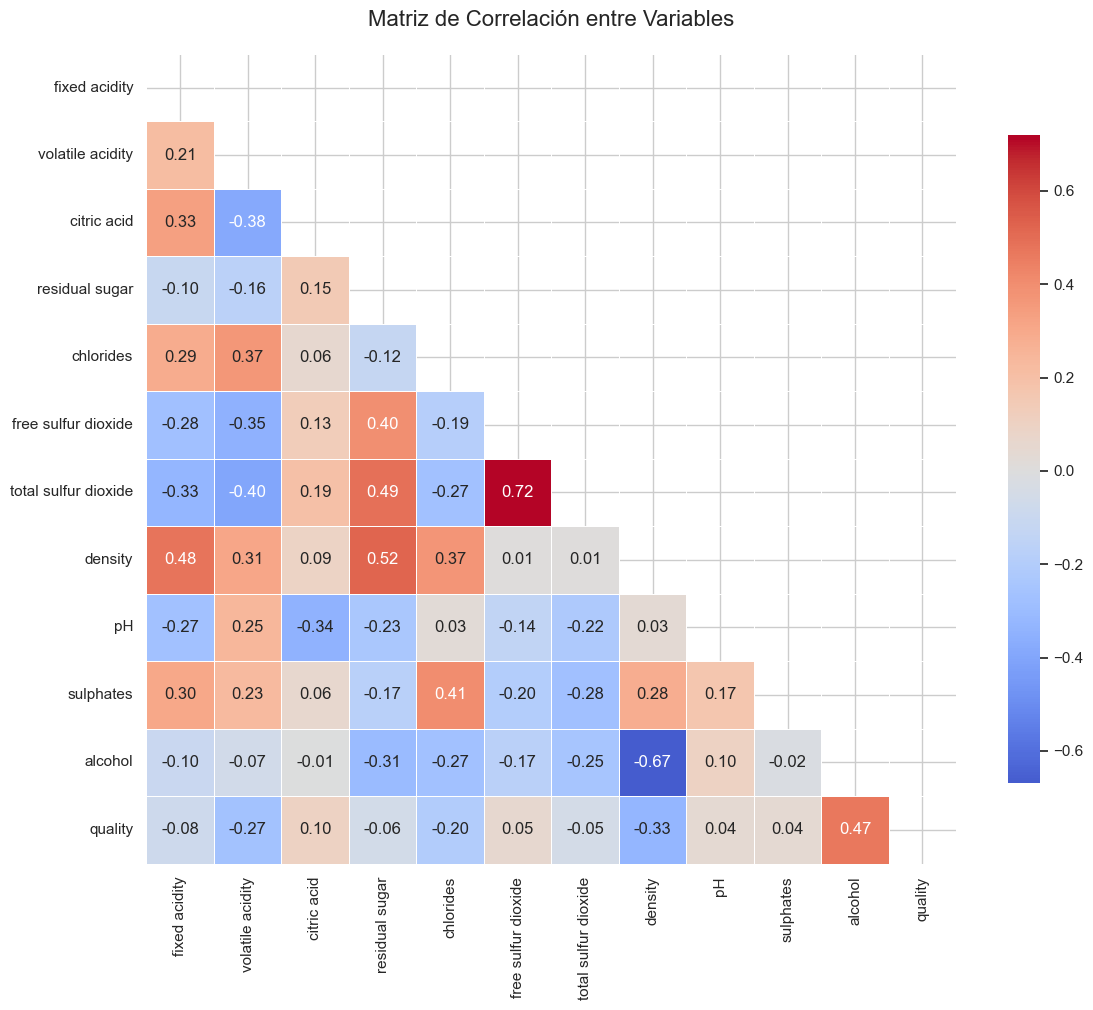

In [19]:
# Matriz de correlación
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, ax=ax, 
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación entre Variables', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

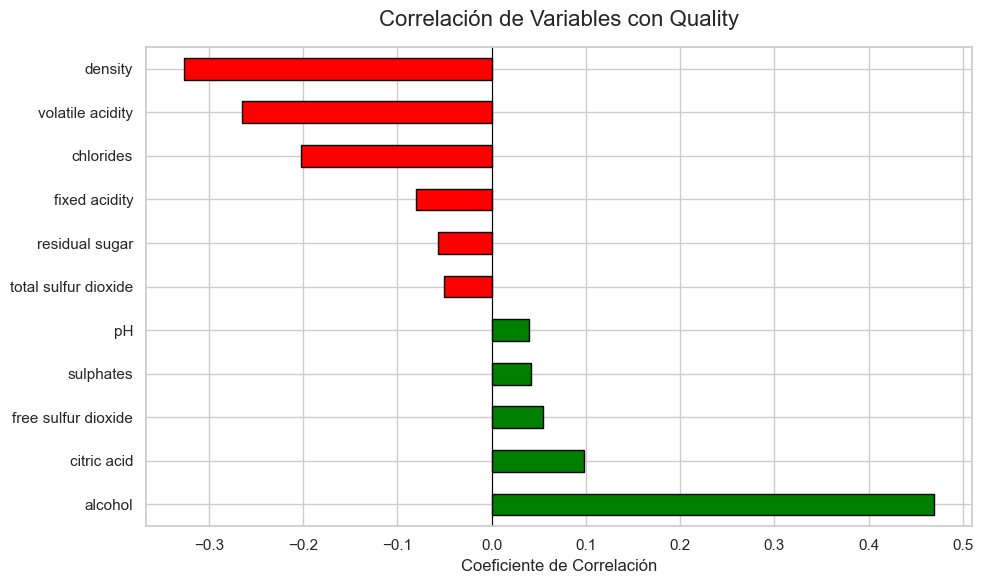


=== Variables Más Correlacionadas con Quality ===

Correlación positiva (a mayor valor, mayor calidad):
  - alcohol: 0.469
  - citric acid: 0.098
  - free sulfur dioxide: 0.054
  - sulphates: 0.042
  - pH: 0.040

Correlación negativa (a mayor valor, menor calidad):
  - total sulfur dioxide: -0.050
  - residual sugar: -0.057
  - fixed acidity: -0.080
  - chlorides: -0.202
  - volatile acidity: -0.265
  - density: -0.326


In [20]:
# Correlaciones con la variable 'quality'
quality_corr = corr_matrix['quality'].drop('quality').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in quality_corr.values]
quality_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Correlación de Variables con Quality', fontsize=16, pad=15)
ax.set_xlabel('Coeficiente de Correlación', fontsize=12)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n=== Variables Más Correlacionadas con Quality ===")
print("\nCorrelación positiva (a mayor valor, mayor calidad):")
for var, corr in quality_corr[quality_corr > 0].items():
    print(f"  - {var}: {corr:.3f}")

print("\nCorrelación negativa (a mayor valor, menor calidad):")
for var, corr in quality_corr[quality_corr < 0].items():
    print(f"  - {var}: {corr:.3f}")

## 9. Distribución de Variables

Visualizamos la distribución de las características principales y su relación con la calidad del vino.

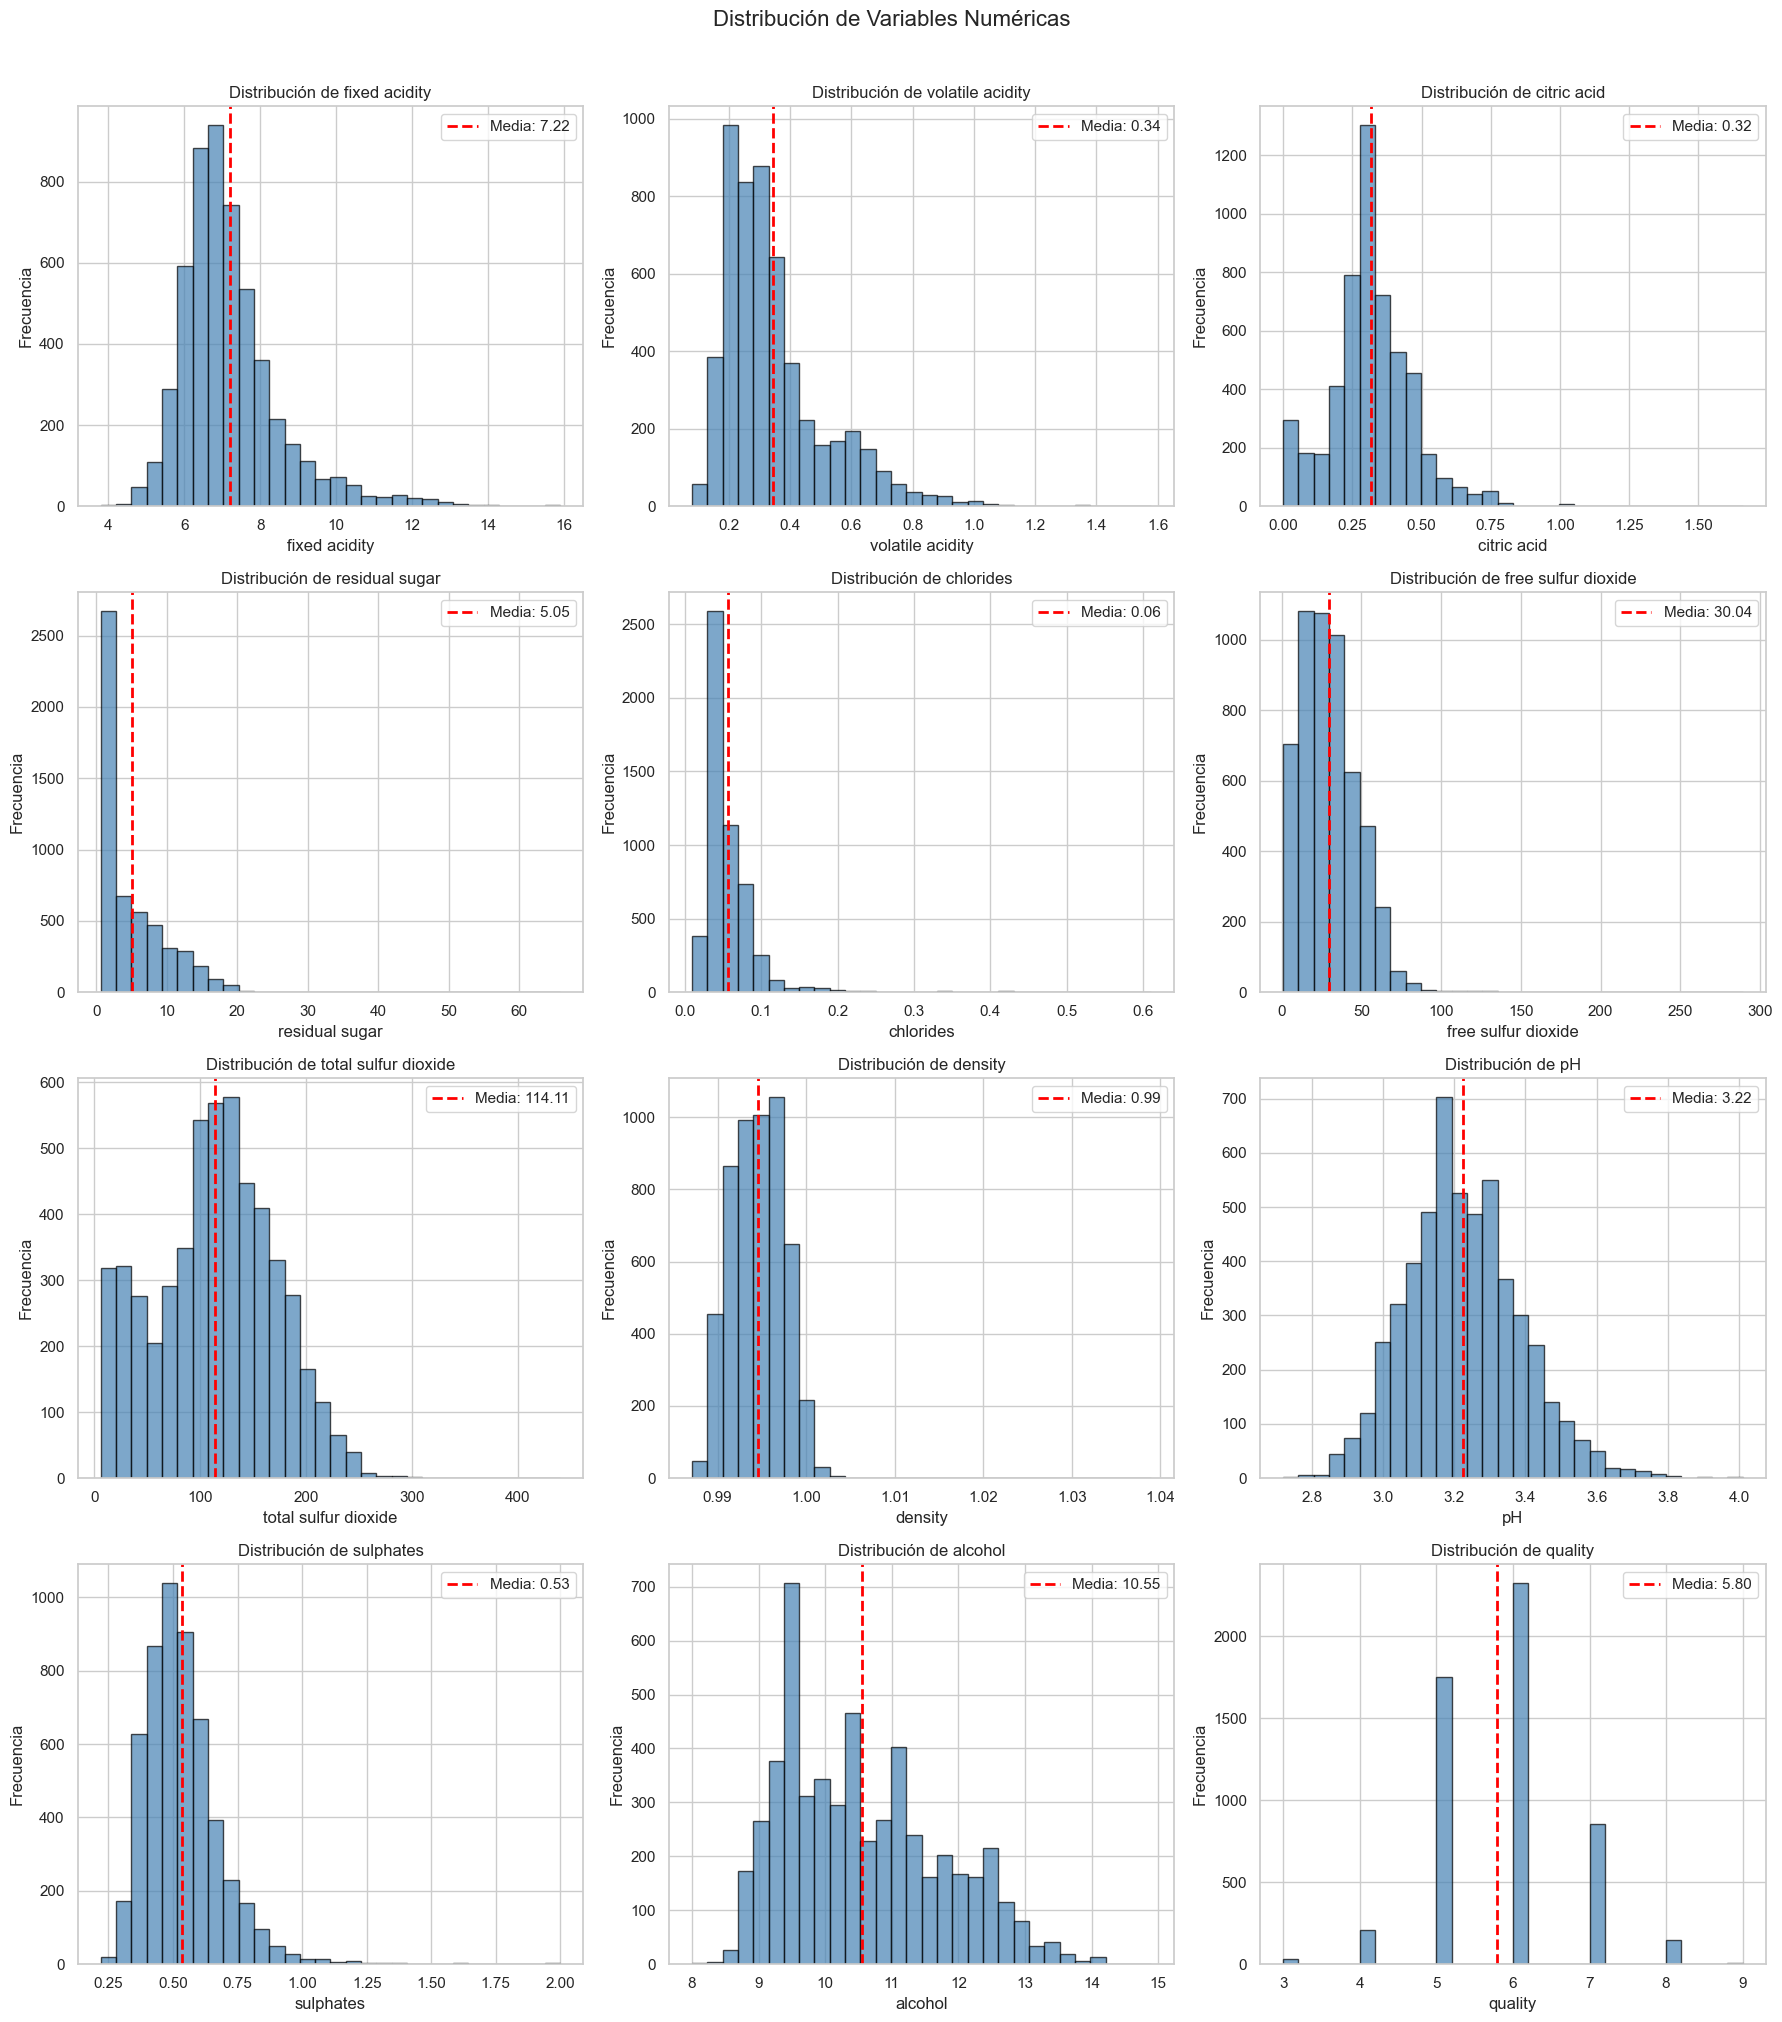

In [21]:
# Histogramas de las variables numéricas
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    # Agregar línea de media
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df[col].mean():.2f}')
    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribución de Variables Numéricas', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\Brandon\AppData\Local\Temp\ipykernel_12584\2024638045.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y=feature, ax=axes[i], palette='viridis')
C:\Users\Brandon\AppData\Local\Temp\ipykernel_12584\2024638045.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y=feature, ax=axes[i], palette='viridis')
C:\Users\Brandon\AppData\Local\Temp\ipykernel_12584\2024638045.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y=feature, ax=axes[i], palette='viridis')
C:\Users\B

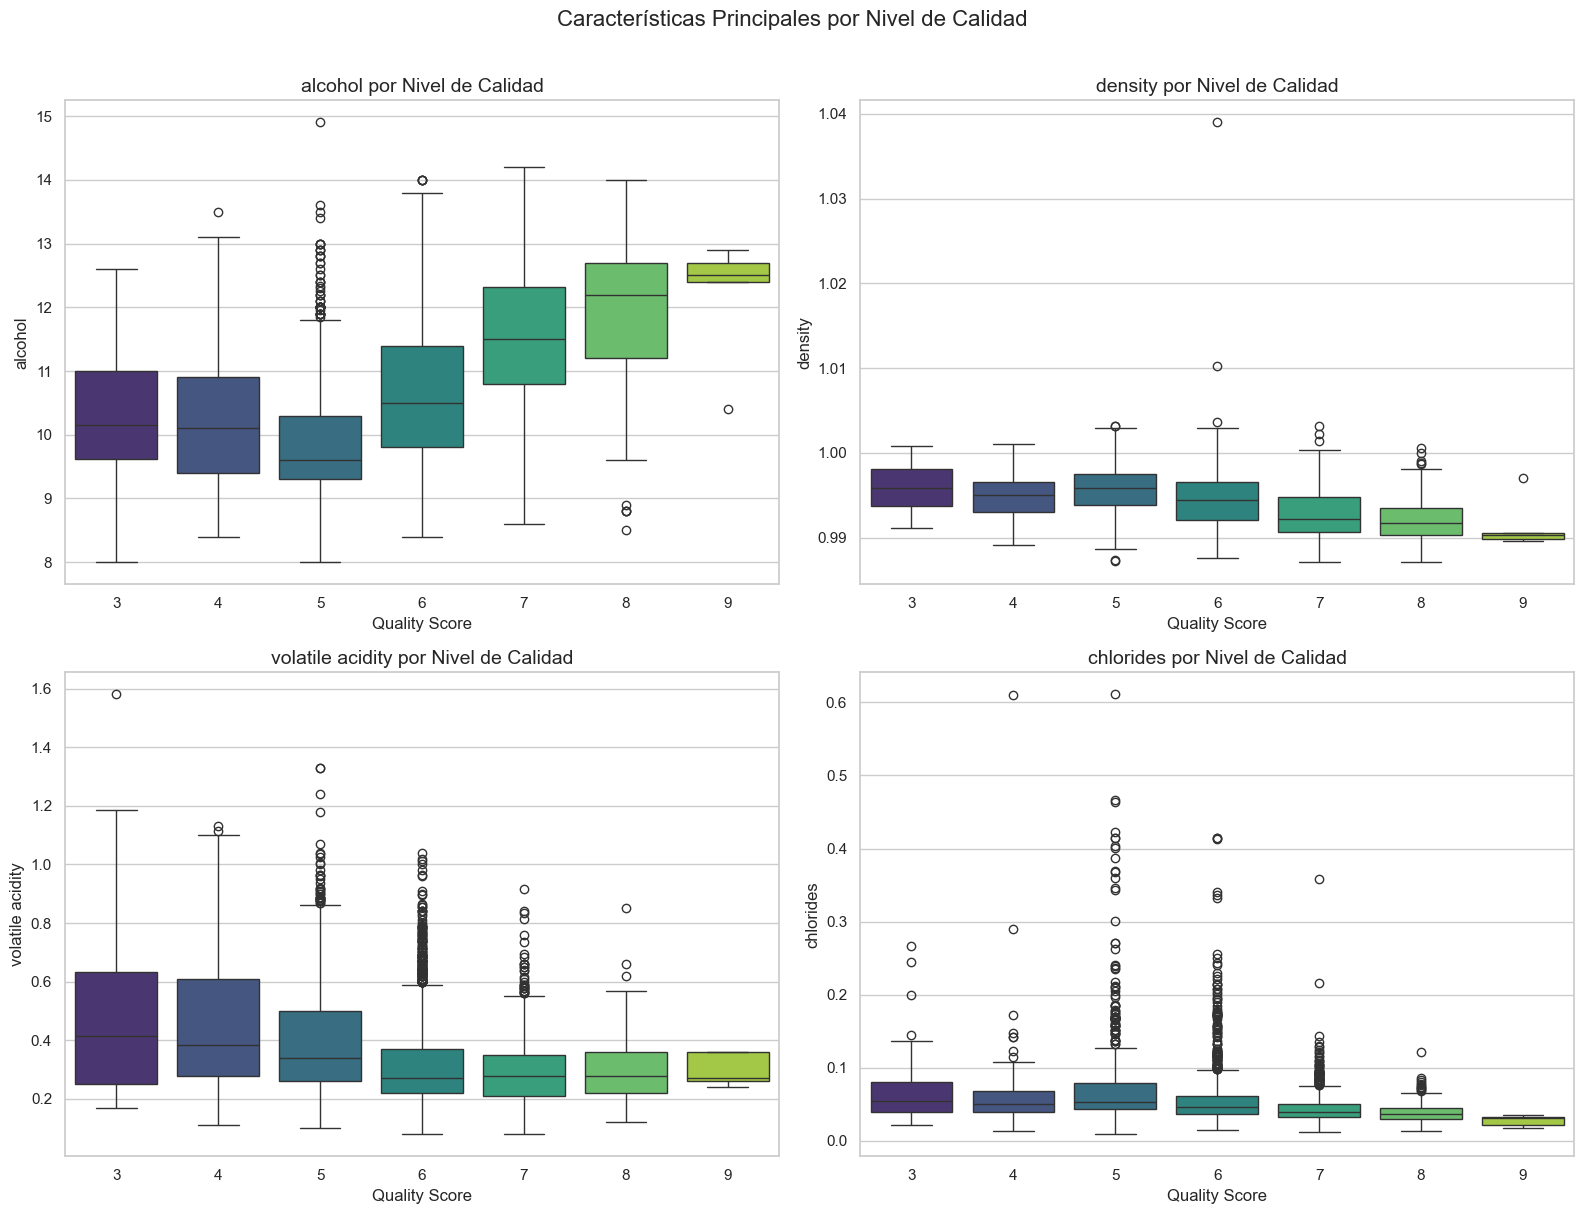


=== Variables Analizadas ===
Las 4 variables con mayor correlación (absoluta) con quality son:
  - alcohol: 0.469
  - density: -0.326
  - volatile acidity: -0.265
  - chlorides: -0.202


In [22]:
# Boxplots de las características más correlacionadas con quality agrupados por calidad
top_features = quality_corr.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(data=df, x='quality', y=feature, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{feature} por Nivel de Calidad', fontsize=14)
    axes[i].set_xlabel('Quality Score', fontsize=12)
    axes[i].set_ylabel(feature, fontsize=12)

plt.suptitle('Características Principales por Nivel de Calidad', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print(f"\n=== Variables Analizadas ===")
print(f"Las 4 variables con mayor correlación (absoluta) con quality son:")
for feat in top_features:
    print(f"  - {feat}: {quality_corr[feat]:.3f}")

## 10. Comparación entre Vinos Tintos y Blancos

Analizamos las diferencias significativas entre las características de vinos tintos y blancos.

In [23]:
# Comparación de medias entre vinos tintos y blancos
comparison = df.groupby('wine_type')[numeric_cols].mean().round(2)
comparison = comparison.T
comparison['difference'] = (comparison['white'] - comparison['red']).abs()
comparison = comparison.sort_values('difference', ascending=False)

print("=== Diferencias de Medias entre Vino Blanco y Tinto ===")
print("(Ordenadas por magnitud de diferencia)")
comparison

=== Diferencias de Medias entre Vino Blanco y Tinto ===
(Ordenadas por magnitud de diferencia)


wine_type,red,white,difference
total sulfur dioxide,46.83,137.19,90.36
free sulfur dioxide,15.89,34.89,19.00
residual sugar,2.52,5.91,3.39
fixed acidity,8.31,6.84,1.47
volatile acidity,0.53,0.28,0.25
quality,5.62,5.85,0.23
sulphates,0.66,0.49,0.17
alcohol,10.43,10.59,0.16
pH,3.31,3.20,0.11
citric acid,0.27,0.33,0.06


C:\Users\Brandon\AppData\Local\Temp\ipykernel_12584\7083366.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='wine_type', y=feature, ax=axes[i], palette=['red', 'gold'])
C:\Users\Brandon\AppData\Local\Temp\ipykernel_12584\7083366.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='wine_type', y=feature, ax=axes[i], palette=['red', 'gold'])
C:\Users\Brandon\AppData\Local\Temp\ipykernel_12584\7083366.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='wine_type', y=feature, ax=axes[i], palette=['red', 'gol

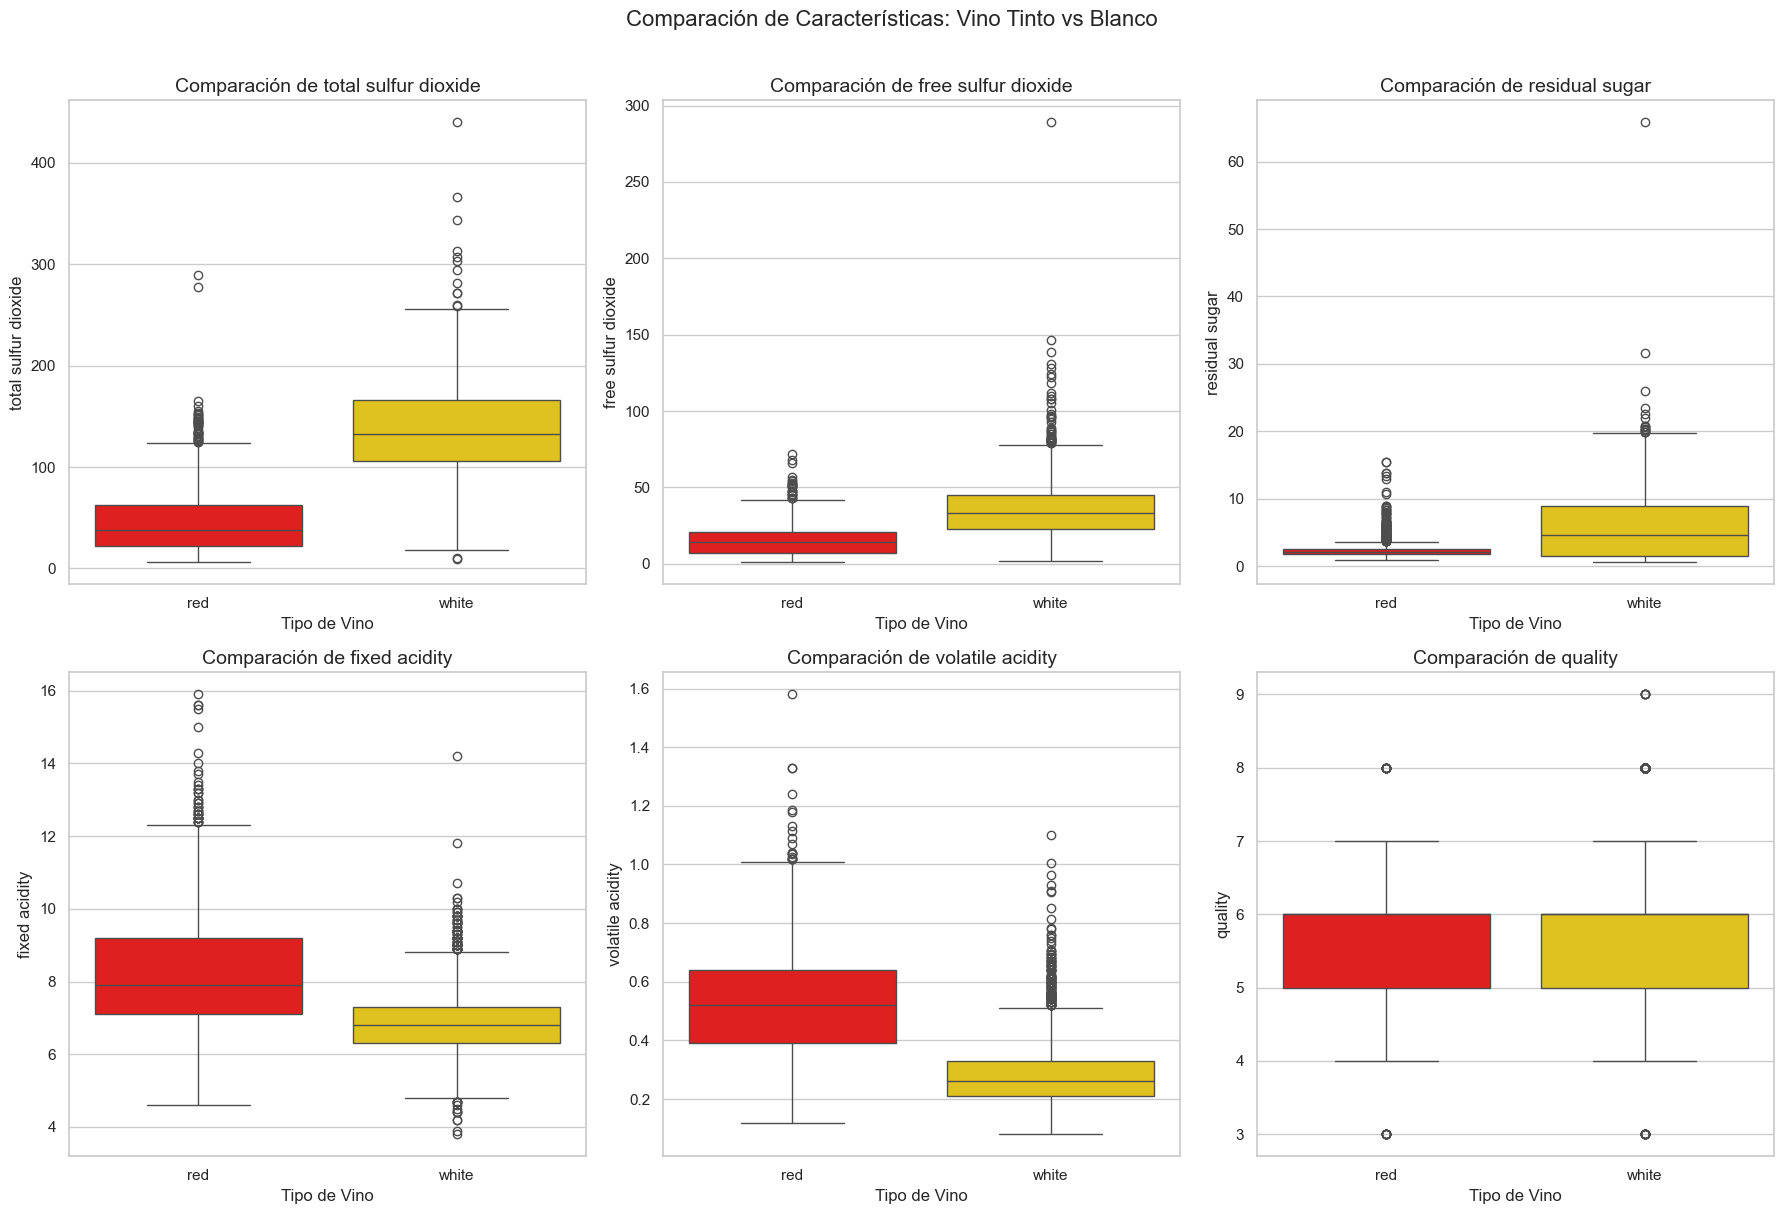


=== Observaciones Principales ===
- total sulfur dioxide: Red=46.83, White=137.19
- free sulfur dioxide: Red=15.89, White=34.89
- residual sugar: Red=2.52, White=5.91


In [24]:
# Visualización comparativa de las variables con mayor diferencia
top_diff_features = comparison.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(top_diff_features):
    sns.boxplot(data=df, x='wine_type', y=feature, ax=axes[i], palette=['red', 'gold'])
    axes[i].set_title(f'Comparación de {feature}', fontsize=14)
    axes[i].set_xlabel('Tipo de Vino', fontsize=12)
    axes[i].set_ylabel(feature, fontsize=12)

plt.suptitle('Comparación de Características: Vino Tinto vs Blanco', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print("\n=== Observaciones Principales ===")
for feature in top_diff_features[:3]:
    red_mean = df[df['wine_type'] == 'red'][feature].mean()
    white_mean = df[df['wine_type'] == 'white'][feature].mean()
    print(f"- {feature}: Red={red_mean:.2f}, White={white_mean:.2f}")

=== Pairplot de Variables Clave ===
(Esta visualización puede tardar unos segundos)


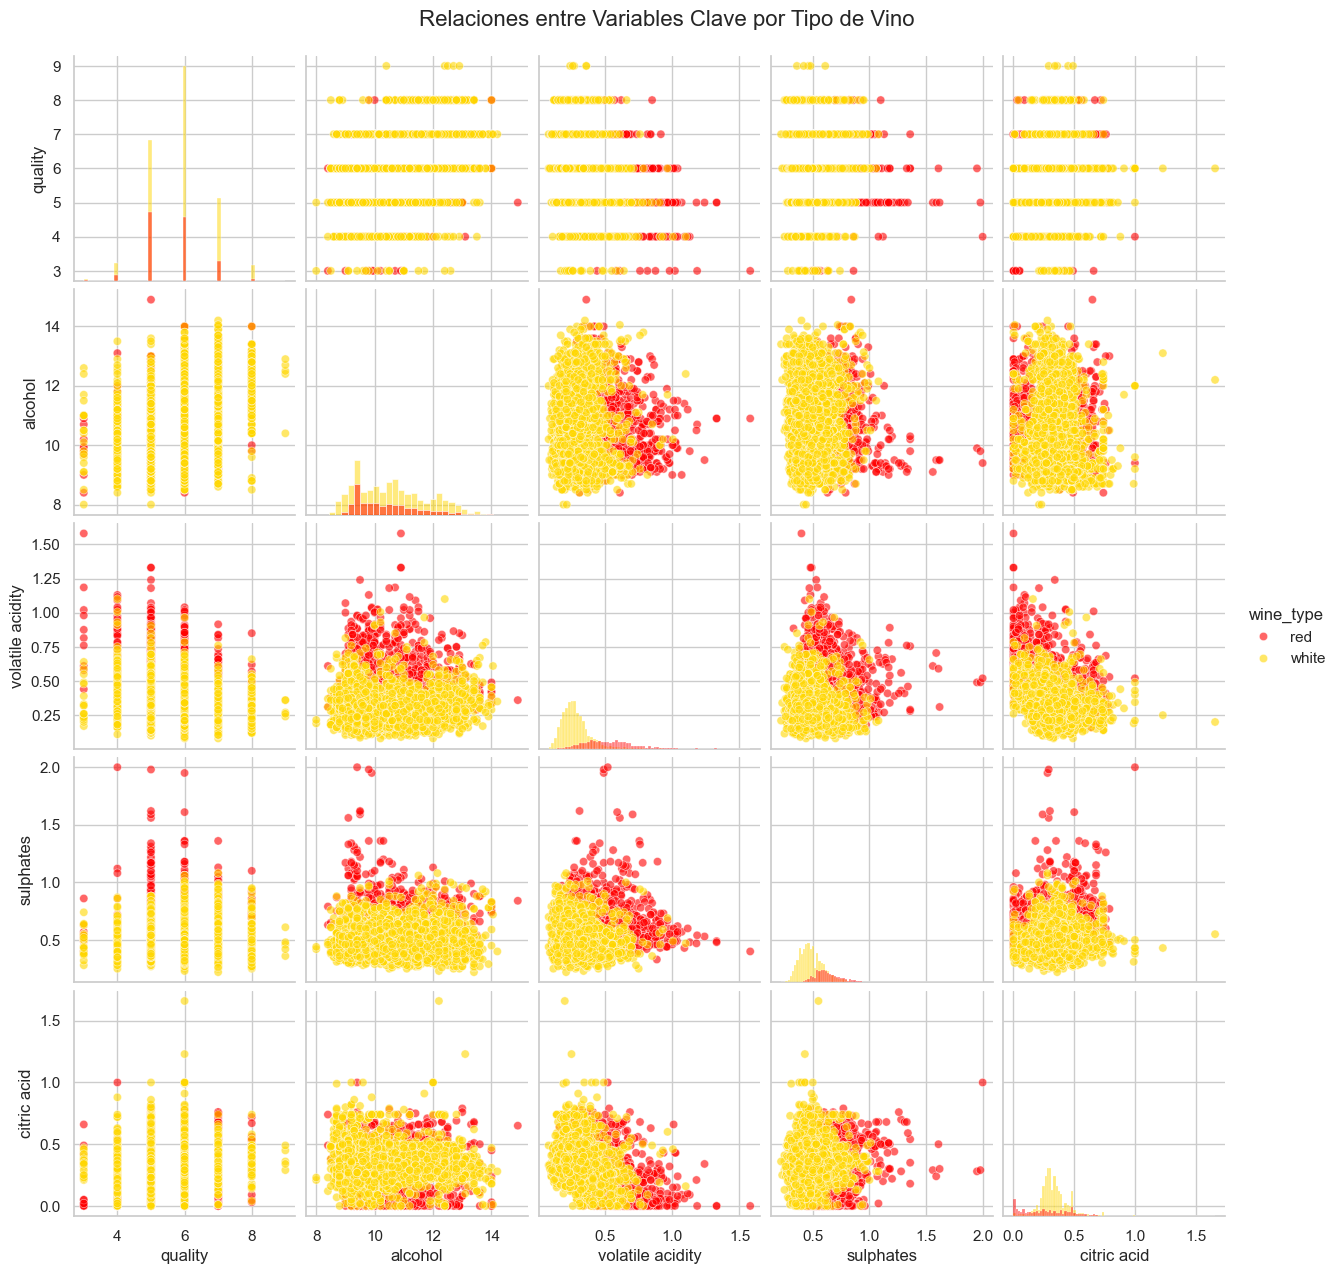

In [26]:
# Pairplot de las variables más importantes
print("=== Pairplot de Variables Clave ===")
print("(Esta visualización puede tardar unos segundos)")

cols_to_plot = ['quality', 'alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'wine_type']
pairplot = sns.pairplot(df[cols_to_plot], hue='wine_type', palette={'red': 'red', 'white': 'gold'}, 
                        diag_kind='hist', plot_kws={'alpha': 0.6})
pairplot.fig.suptitle('Relaciones entre Variables Clave por Tipo de Vino', y=1.02, fontsize=16)
plt.show()

## Resumen del Análisis Exploratorio

### Hallazgos principales

1. **Tamaño y limpieza del dataset**
   - Se partió de **6,497 registros** (1,599 tintos y 4,898 blancos).
   - Se detectaron **1,177 duplicados** y, tras eliminarlos, el dataset quedó en **5,320 observaciones**.
   - No se encontraron valores nulos y los tipos de datos quedaron consistentes para el análisis.

2. **La calidad está fuertemente concentrada en valores medios**
   - Distribución final: calidad 6 (**43.67%**), calidad 5 (**32.93%**), calidad 7 (**16.09%**).
   - Las calidades extremas son muy escasas: 3 (**0.56%**) y 9 (**0.09%**).
   - La variable objetivo está desbalanceada hacia clases medias, lo que afecta la capacidad de distinguir vinos excepcionales o muy deficientes.

3. **Diferencias entre vino tinto y blanco**
   - Calidad promedio: **blanco = 5.85**, **tinto = 5.62** (los blancos muestran ligera ventaja media de ~0.23 puntos).
   - Las mayores diferencias fisicoquímicas entre tipos aparecen en:
     - **total sulfur dioxide** (red=46.83 vs white=137.19),
     - **free sulfur dioxide** (red=15.89 vs white=34.89),
     - **residual sugar** (red=2.52 vs white=5.91).
   - Los tintos, en cambio, presentan mayor **fixed acidity** y **volatile acidity** en promedio.

4. **Variables más asociadas con la calidad**
   - Correlaciones positivas con `quality`: **alcohol (0.469)**, **citric acid (0.098)**, **free sulfur dioxide (0.054)**.
   - Correlaciones negativas con `quality`: **density (-0.326)**, **volatile acidity (-0.265)**, **chlorides (-0.202)**.
   - Interpretación: el **alcohol** es el factor lineal más influyente observado; por otro lado, vinos más densos, con más acidez volátil y más cloruros tienden a menor calidad.

5. **Patrones en los boxplots por nivel de calidad**
   - A medida que sube la calidad, se observa una tendencia clara a **mayor alcohol**.
   - También se aprecia una reducción gradual de **density**, **volatile acidity** y **chlorides** en niveles de calidad altos.
   - Esto refuerza visualmente la dirección de las correlaciones encontradas.

6. **Outliers y variabilidad**
   - Hay outliers en varias variables; por frecuencia destacan **fixed acidity**, **volatile acidity** y **chlorides**.
   - Por magnitud, se observan extremos importantes en **residual sugar** y dióxidos de azufre.
   - Dado que son mediciones químicas reales, conviene tratarlos con métodos robustos (winsorización, escalado robusto o modelos menos sensibles), no eliminarlos automáticamente.

### Conclusión general

El EDA muestra que la calidad del vino en este conjunto está dominada por niveles intermedios y que la separación entre vinos de alta y baja calidad se explica principalmente por el balance entre **alcohol** (positivo) y **density / volatile acidity / chlorides** (negativos). Además, existen perfiles químicos claramente distintos entre vinos tintos y blancos, por lo que **incluir `wine_type` y/o modelar por tipo** puede mejorar el desempeño analítico y predictivo.